# Decision Tree

A decision tree splits the dataset based on feature values to create pure subsets ideally all items in a group belong to the same class. Each leaf node of the tree corresponds to a class label and the internal nodes are feature-based decision points. A decision tree is a supervised learning algorithm used for both classification and regression tasks. It has a hierarchical tree structure which consists of a root node, branches, internal nodes and leaf nodes.

## Information Gain - 
<br> Information Gain tells us how useful a question (or feature) is for splitting data into groups. It measures how much the uncertainty decreases after the split. A good question will create clearer groups and the feature with the highest Information Gain is chosen to make the decision
<br>
suppose 
S is a set of instances 
A is an attribute, 
Sv is the subset of 
S, 
v represents an individual value that the attribute 
A can take and Values (
A) is the set of all possible values of 
A then
Entropy: It is the measure of uncertainty of a random variable, it characterizes the impurity of an arbitrary collection of examples. The higher the entropy more the information content.

## Gini Index
<br>
Gini Index is a metric to measure how often a randomly chosen element would be incorrectly identified. It means an attribute with a lower Gini index should be preferred. Sklearn supports “Gini” criteria for Gini Index and by default it takes “gini” value

 class sklearn.tree.DecisionTreeClassifier(
     *,
     criterion='gini',
     splitter='best',
     max_depth=None,
     min_samples_split=2,
     min_samples_leaf=1,
     min_weight_fraction_leaf=0.0,
     max_features=None,
     random_state=None,
     max_leaf_nodes=None,
     min_impurity_decrease=0.0,
     class_weight=None,
     ccp_alpha=0.0,
     monotonic_cst=None
 )

Parameters:
<br>
<br>
criterion: Metric used to evaluate split quality (gini, entropy, log_loss)<br>
splitter: Strategy for choosing splits (best or random).<br>
max_features: Number of features considered for each split.<br>
max_depth: Maximum depth of the tree.<br>
min_samples_split: Minimum samples required to split a node.<br>
min_samples_leaf: Minimum samples required at a leaf node.<br>
max_leaf_nodes: Maximum number of leaf nodes.<br>
min_impurity_decrease: Minimum impurity reduction required to split a node.<br>
class_weight: Balances class distribution by assigning weights.<br>
ccp_alpha: Controls pruning strength to reduce overfitting<br>

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [2]:
data = load_iris()
X = data.data  
y = data.target

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state = 99)

In [4]:
clf = DecisionTreeClassifier(random_state=1)

In [5]:
clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [6]:
y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

Accuracy: 0.9555555555555556


In [7]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': range(1, 10, 1),
    'min_samples_leaf': range(1, 20, 2),
    'min_samples_split': range(2, 20, 2),
    'criterion': ["entropy", "gini"]
}

tree = DecisionTreeClassifier(random_state=1)

grid_search = GridSearchCV(estimator=tree, param_grid=param_grid, 
                           cv=5, verbose=True)
grid_search.fit(X_train, y_train)

print("best accuracy", grid_search.best_score_)
print(grid_search.best_estimator_)

Fitting 5 folds for each of 1620 candidates, totalling 8100 fits
best accuracy 0.9714285714285715
DecisionTreeClassifier(criterion='entropy', max_depth=4, min_samples_leaf=3,
                       random_state=1)


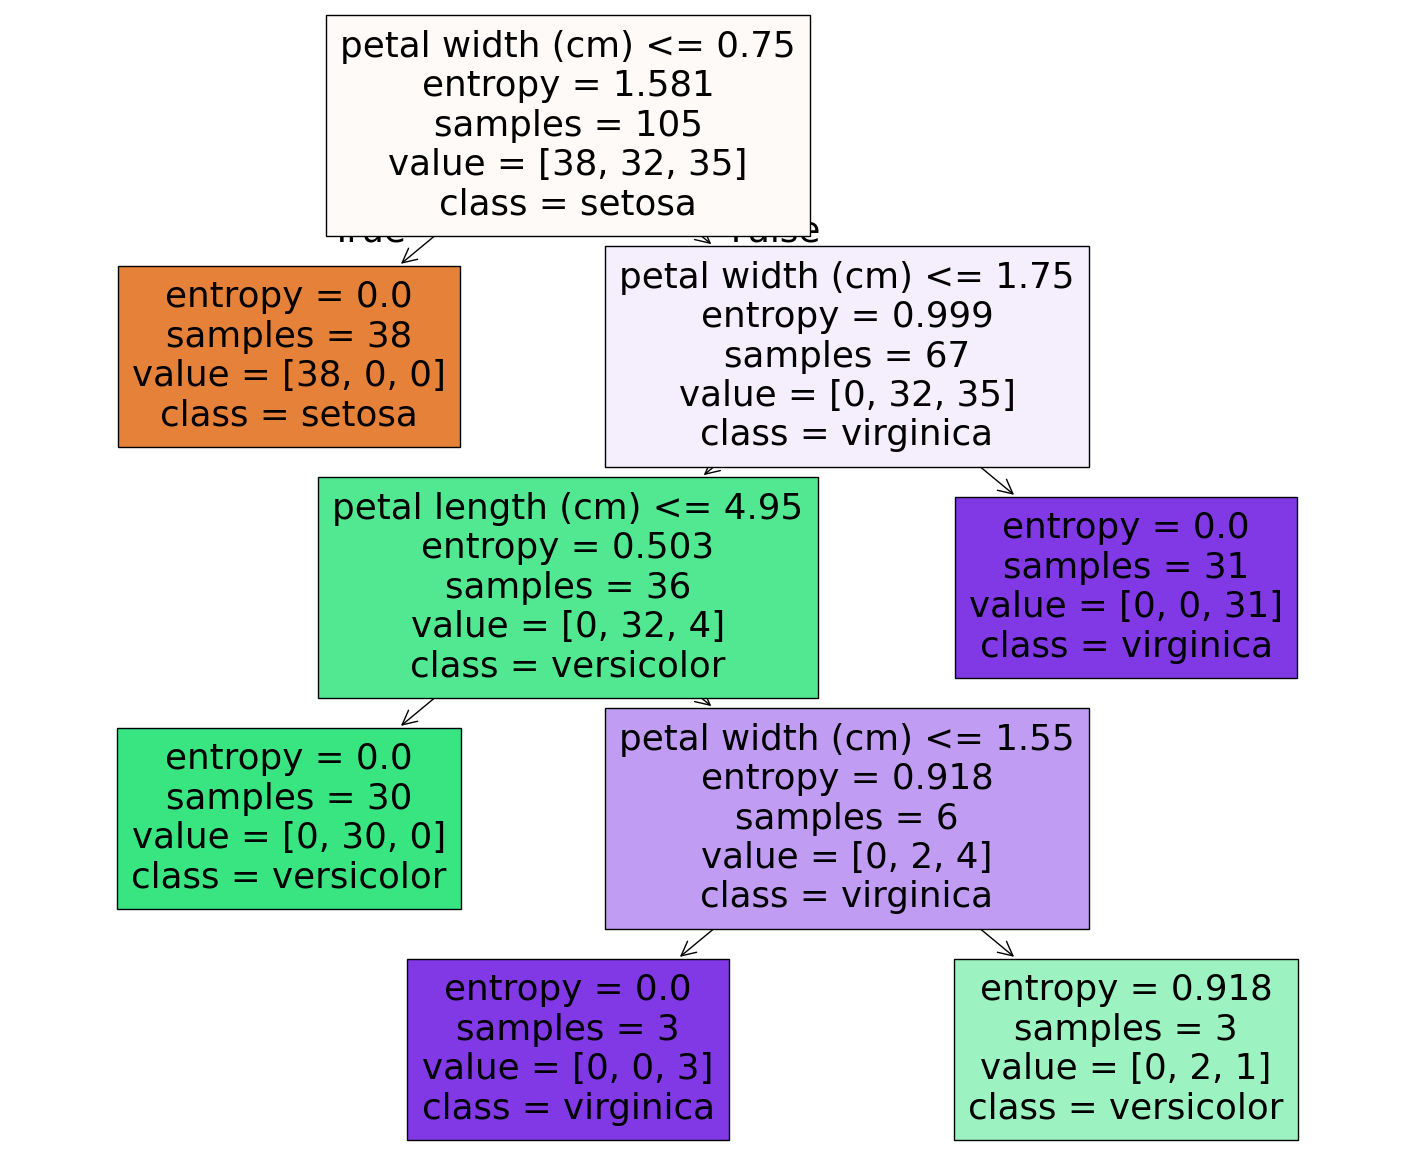

In [8]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
 
tree_clf = grid_search.best_estimator_

plt.figure(figsize=(18, 15))
plot_tree(tree_clf, filled=True, feature_names=data.feature_names,
          class_names=data.target_names)
plt.show()

min_impurity_decrease: A node will only split if the "purity gain" (like Information Gain) is higher than this value. It ensures the tree only makes splits that actually add meaningful value.
class_weight: Used when your classes are unbalanced (e.g., 99% "No" and 1% "Yes"). It tells the tree to pay more attention to the minority class so it doesn't just predict "No" every time.
ccp_alpha: This stands for Cost Complexity Pruning. It "trims" the tree after it’s fully grown. A higher alpha results in more pruning, leaving you with a smaller, more general tree.
max_features: This limits the number of features the tree "looks at" when deciding a split. If you have 100 features but set this to 10, the tree only considers a random subset of 10 at each node. This is a key ingredient in Random Forests.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

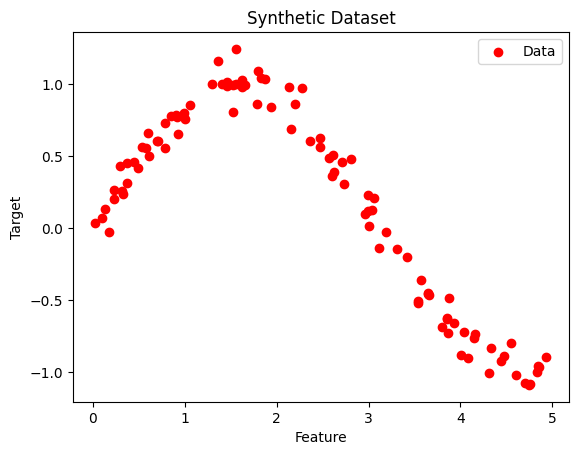

In [3]:
np.random.seed(42)
X = np.sort(5 * np.random.rand(100, 1), axis=0)
y = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0])

plt.scatter(X, y, color='red', label='Data')
plt.title("Synthetic Dataset")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.legend()
plt.show()

 X = np.sort(5 * np.random.rand(100, 1), axis=0)
np.random.rand(100, 1): Generates a 100x1 column vector (100 rows, 1 column) of random numbers uniformly distributed between 0 and 1.
5 * ...: Scales these numbers to be between 0 and 5, creating a range of feature values from 0 to 5.
np.sort(..., axis=0): Sorts the 100 values in ascending order along the rows (axis=0). This ensures X represents a sequential timeline or ordered input, rather than unordered dots.
Result: X is an array of 100 sorted numbers between 0 and 5, representing the feature (input) data. 
NumPy
NumPy
 +3
3. y = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0])
np.sin(X).ravel(): Calculates the sine of every value in X to create the target signal. .ravel() flattens the result from a 2D column vector into a 1D array, making it compatible for model fitting.
np.random.normal(0, 0.1, X.shape[0]): Adds Gaussian noise to the data. It generates 100 samples (matching the size of X) from a normal distribution with a mean (
) of 0 and a standard deviation (
) of 0.1.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [5]:
regressor = DecisionTreeRegressor(max_depth=4, random_state=42)

In [6]:
regressor.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [7]:
y_pred = regressor.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.4f}")

Mean Squared Error: 0.0151


C:\Users\RICHA MISHRA\AppData\Local\Temp\ipykernel_25896\3277648091.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.01)[:, np.newaxis]


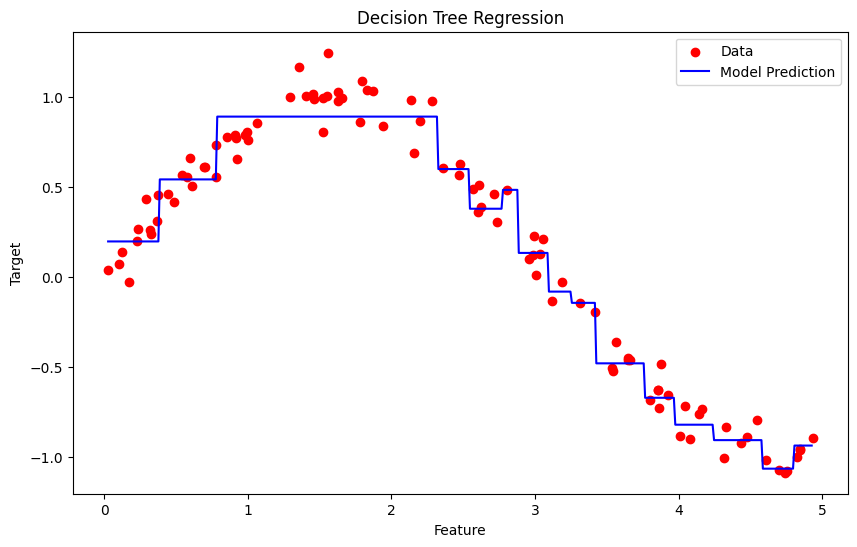

In [8]:
X_grid = np.arange(min(X), max(X), 0.01)[:, np.newaxis]
y_grid_pred = regressor.predict(X_grid)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='red', label='Data')
plt.plot(X_grid, y_grid_pred, color='blue', label='Model Prediction')
plt.title("Decision Tree Regression")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.legend()
plt.show()

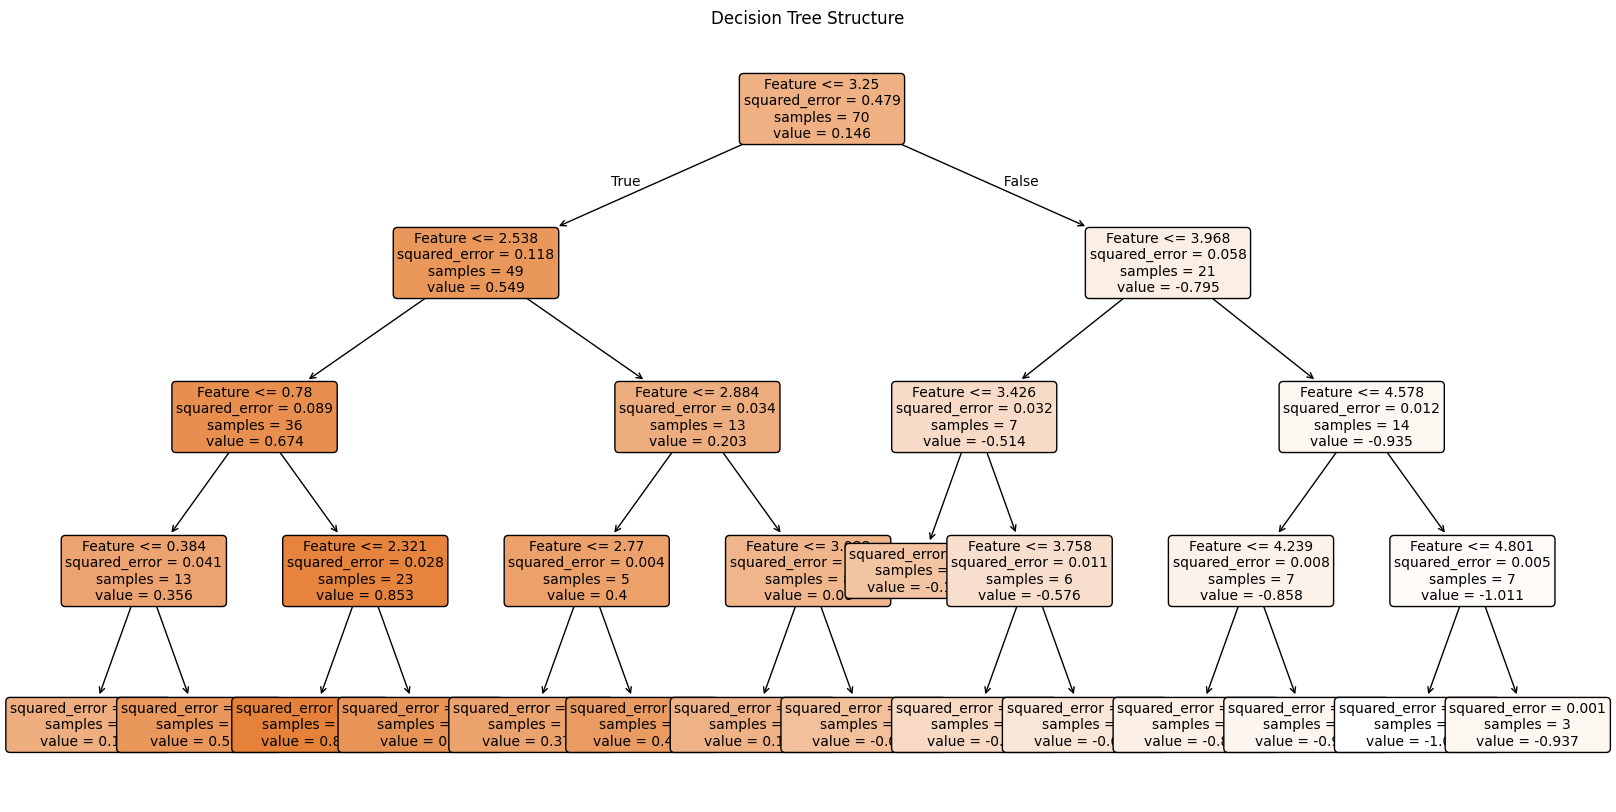

In [9]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    regressor,
    feature_names=["Feature"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Structure")
plt.show()